In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import ( 
    Input, Conv1D, Concatenate, BatchNormalization, ReLU, 
    Add, GlobalAveragePooling1D, Dense, Dropout, MultiHeadAttention, LayerNormalization) 
from tensorflow.keras.models import Model, load_model
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint
from tensorflow.keras.losses import KLDivergence
from tensorflow.keras.optimizers import Adam

import seaborn as sns
import pandas as pd

import datetime
from helper_functions import read_composition

from CNN import build_CNN
from Load_data import load_real_data, load_synthetic_data, load_bootstrapped_data, load_real_data_6_element_phantom
from metrics import mae_O, mae_C, mae_N#, median_ae_O, median_ae_C, median_ae_N
from loss import make_weighted_loss

2026-05-13 11:33:01.204352: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-13 11:33:01.204387: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-13 11:33:01.205868: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-13 11:33:01.213761: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-13 11:33:02.132029: W tensorflow/comp

### Datasets

In [2]:
data_path_100mill = r"/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/Data_100mill/"
data_path_100mill_300 = r"/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/Data_100mill/nesten_300_nye/"

data_path_1mrd = "/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/Data_1mrd/"
data_path_1mrd_10 = "/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/Data_1mrd/10_nye/"
data_path_1mrd_20 = "/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/Data_1mrd/20_nye/"
data_path_1mrd_20_til = "/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/Data_1mrd/20_nye_til/"
data_path_1mrd_60 = "/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/Data_1mrd/60_nye_simuleringer/"

X_array, y_array = load_real_data(data_path = data_path_100mill)#, w_gradient=True)
X_array_300, y_array_300 = load_real_data(data_path = data_path_100mill_300, foldername_kde="/tki_kde")#, w_gradient=True)

X_array = np.concatenate((X_array, X_array_300), axis = 0)
y_array = np.concatenate((y_array, y_array_300), axis = 0)

X_array_1mrd, y_array_1mrd = load_real_data(data_path= data_path_1mrd, foldername_kde="/tki_kde")
X_array_1mrd_10, y_array_1mrd_10 = load_real_data(data_path= data_path_1mrd_10, foldername_kde="/tki_kde")
X_array_1mrd_20, y_array_1mrd_20 = load_real_data(data_path= data_path_1mrd_20, foldername_kde="/tki_kde")
X_array_1mrd_20_til, y_array_1mrd_20_til = load_real_data(data_path= data_path_1mrd_20_til, foldername_kde="/tki_kde")
X_array_1mrd_60, y_array_1mrd_60 = load_real_data(data_path= data_path_1mrd_60, foldername_kde="/tki_kde")

X_array_1mrd = np.concatenate((X_array_1mrd, X_array_1mrd_10, X_array_1mrd_20, X_array_1mrd_20_til, X_array_1mrd_60), axis = 0)
y_array_1mrd = np.concatenate((y_array_1mrd, y_array_1mrd_10, y_array_1mrd_20, y_array_1mrd_20_til, y_array_1mrd_60), axis = 0)


print("X_array shape:", X_array.shape)
print("y_array shape:", y_array.shape)
print("X_array_1mrd shape:", X_array_1mrd.shape)
print("y_array_1mrd shape:", y_array_1mrd.shape)

y_array_1mrd_128 = np.delete(y_array_1mrd, 4, axis = 0)
X_array_1mrd_128 = np.delete(X_array_1mrd, 4, axis = 0)

X_train_1, X_val_1, y_train_1, y_val_1 = train_test_split(X_array,y_array, test_size = 0.20, random_state = 42)
X_train_2, X_val_test_2, y_train_2, y_val_test_2 = train_test_split(X_array_1mrd_128,y_array_1mrd_128, test_size = 0.25, random_state = 42)
X_test_2, X_val_2, y_test_2, y_val_2 = train_test_split(X_val_test_2,y_val_test_2,test_size = 0.5, random_state = 42)
print("Dataset 1: ")
print("X_train_1 (shape): ", X_train_1.shape)
print("X_val_1 (shape): ", X_val_1.shape)

print("Dataset 2: ")
print("X_train_2 (shape): ", X_train_2.shape)
print("X_val_2 (shape): ", X_val_2.shape)
print("X_test_2 (shape): ", X_test_2.shape)

X_array shape: (458, 350)
y_array shape: (458, 3)
X_array_1mrd shape: (129, 350)
y_array_1mrd shape: (129, 3)
Dataset 1: 
X_train_1 (shape):  (366, 350)
X_val_1 (shape):  (92, 350)
Dataset 2: 
X_train_2 (shape):  (96, 350)
X_val_2 (shape):  (16, 350)
X_test_2 (shape):  (16, 350)


In [47]:
pretrained_model = "/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models/new_filters/val_mae_0.0141_bs32__lr0.00003_epoch_1712_val_mae_O_0.0089_val_mae_C_0.0177_val_mae_N_0.0156_val_median_ae_O_0.0074_val_median_ae_C_0.0170_val_median_ae_N_0.0143_continue.keras"
#"/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models/finetune_bs_fixed_synthetic/val_mae_0.0143_bs8__lr0.00001_epoch_293_val_mae_O_0.0132_val_mae_C_0.0152_val_mae_N_0.0145.keras"

#"/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models/new_filters/val_mae_0.0141_bs32__lr0.00003_epoch_1712_val_mae_O_0.0089_val_mae_C_0.0177_val_mae_N_0.0156_val_median_ae_O_0.0074_val_median_ae_C_0.0170_val_median_ae_N_0.0143_continue.keras"
#"/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models/new_more_data/spect_bs32__lr0.0001_epoch_136_val_mae0.0227_val_mae_O_0.0118_val_mae_C_0.0285_val_mae_N_0.0276.keras" OBS DENNE BLE BRUKT FØR
#"/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models/synthetic/val_mae_0.0023_bs32__lr0.00001_epoch_199_val_mae_O_0.0021_val_mae_C_0.0029_val_mae_N_0.0020.keras"
#"/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models/new_more_data/spect_bs32__lr0.0001_epoch_136_val_mae0.0227_val_mae_O_0.0118_val_mae_C_0.0285_val_mae_N_0.0276.keras"
best_model = load_model(pretrained_model, compile = False)

In [ ]:
prediction_array_X = X_val_1#X_test_2
prediction_array_y = y_val_1#y_test_2

print(prediction_array_X.shape, prediction_array_y.shape)


MAEs = []
labels = []
oksygen_true = []
carbon_true = []
nitrogen_true = []
oksygen_pred = []
carbon_pred = []
nitrogen_pred = []
for i in range(len(prediction_array_X)):
    y_true = prediction_array_y[i]
    y_pred = best_model.predict(prediction_array_X[i].reshape(1, 350, 1))#.reshape(1,350,2))
    MAE = np.mean(np.abs(y_true - y_pred), axis = 0)
    labels.append(y_true)
    MAEs.append(MAE)

    oksygen_true.append(y_true[0])
    carbon_true.append(y_true[1])
    nitrogen_true.append(y_true[2])

    oksygen_pred.append(y_pred[0][0])
    carbon_pred.append(y_pred[0][1])
    nitrogen_pred.append(y_pred[0][2])

print(len(labels))

(92, 350) (92, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
16


[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15.]
Mean absolute error (oxygen): 0.0075
Mean absolute error (carbon): 0.0188
Mean absolute error (nitrogen): 0.0171
------------------------------------------
Median absolute error (oxygen): 0.0065
Median absolute error (carbon): 0.0184
Median absolute error (nitrogen): 0.0134
------------------------------------------


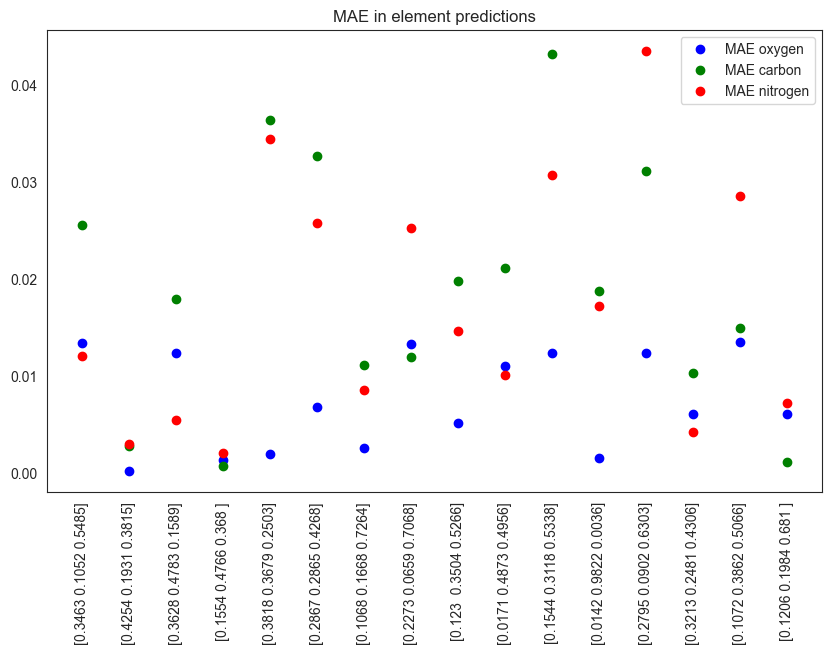

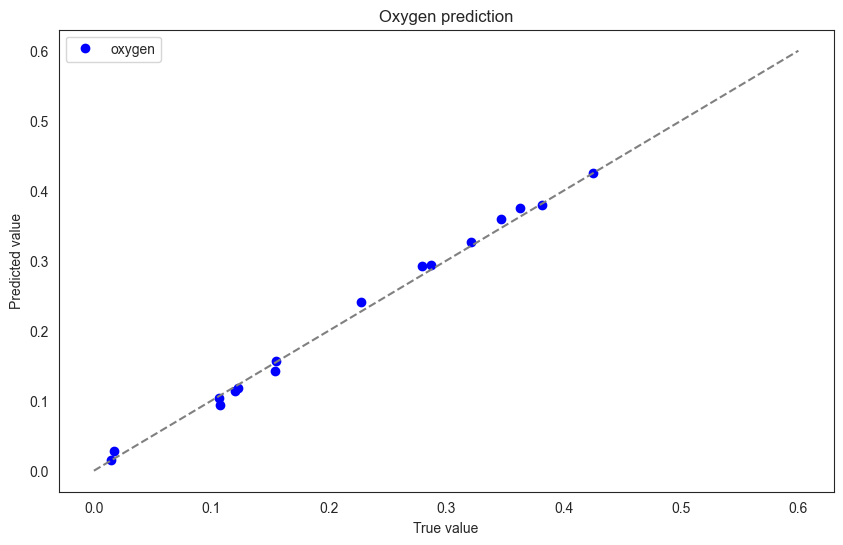

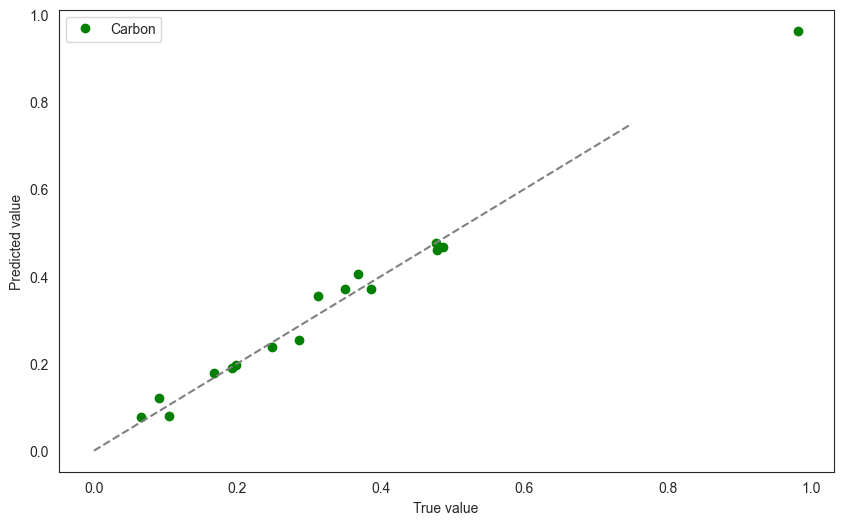

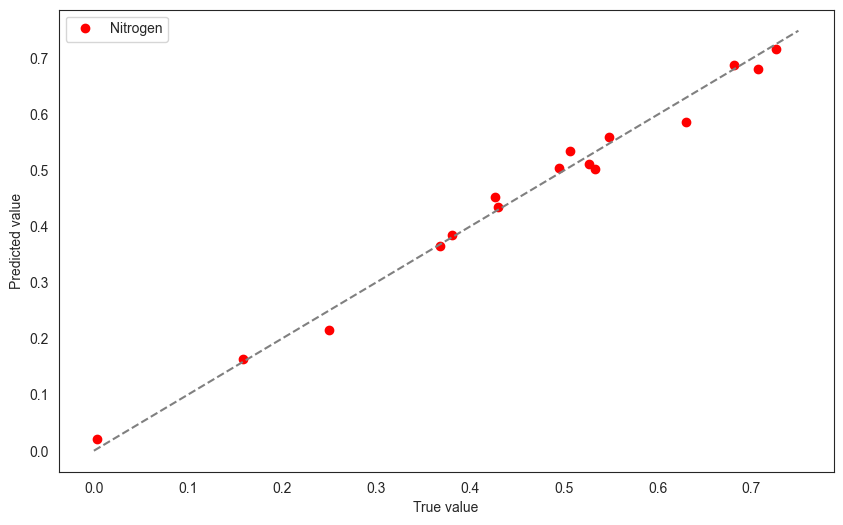

In [51]:
Oxygen_errs = []
Carbon_errs = []
Nitrogen_errs = []
for i in range(len(MAEs)):
    Oxygen_errs.append(MAEs[i][0])
    Carbon_errs.append(MAEs[i][1])
    Nitrogen_errs.append(MAEs[i][2])

A = np.linspace(0,15,16)
print(A)

print("Mean absolute error (oxygen):", np.round(np.mean(Oxygen_errs), 4))
print("Mean absolute error (carbon):", np.round(np.mean(Carbon_errs), 4))
print("Mean absolute error (nitrogen):", np.round(np.mean(Nitrogen_errs), 4))
print("------------------------------------------")


print("Median absolute error (oxygen):", np.round(np.median(Oxygen_errs), 4))
print("Median absolute error (carbon):", np.round(np.median(Carbon_errs), 4))
print("Median absolute error (nitrogen):", np.round(np.median(Nitrogen_errs), 4))
print("------------------------------------------")

plt.figure(figsize=(10,6))
plt.title("MAE in element predictions")
plt.plot(Oxygen_errs, "bo", label = "MAE oxygen")
plt.plot(Carbon_errs, "go", label = "MAE carbon")
plt.plot(Nitrogen_errs, "ro",label = "MAE nitrogen")
plt.xticks(ticks = A , labels=labels, rotation = 90)
plt.legend()
plt.show()

plt.figure(figsize=(10,6))
plt.title("Oxygen prediction")
plt.plot(oksygen_true,oksygen_pred, "bo", label = "oxygen")
arr = np.linspace(0,0.6)
plt.plot(arr,arr, color = "gray", linestyle = "--")
plt.legend()
plt.xlabel("True value")
plt.ylabel("Predicted value")
plt.show()

plt.figure(figsize=(10,6))
plt.plot(carbon_true,carbon_pred, "go", label = "Carbon")
arr = np.linspace(0,0.75)
plt.plot(arr,arr, color = "gray", linestyle = "--")
plt.legend()
plt.xlabel("True value")
plt.ylabel("Predicted value")
plt.show()

plt.figure(figsize=(10,6))
plt.plot(nitrogen_true,nitrogen_pred, "ro", label = "Nitrogen")
arr = np.linspace(0,0.75)
plt.plot(arr,arr, color = "gray", linestyle = "--")
plt.legend()
plt.xlabel("True value")
plt.ylabel("Predicted value")
plt.show()


/tmp/ipykernel_2750649/3755566168.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = "element", y = "value", palette = palette, fill = False, linewidth=1.0, fliersize=4)


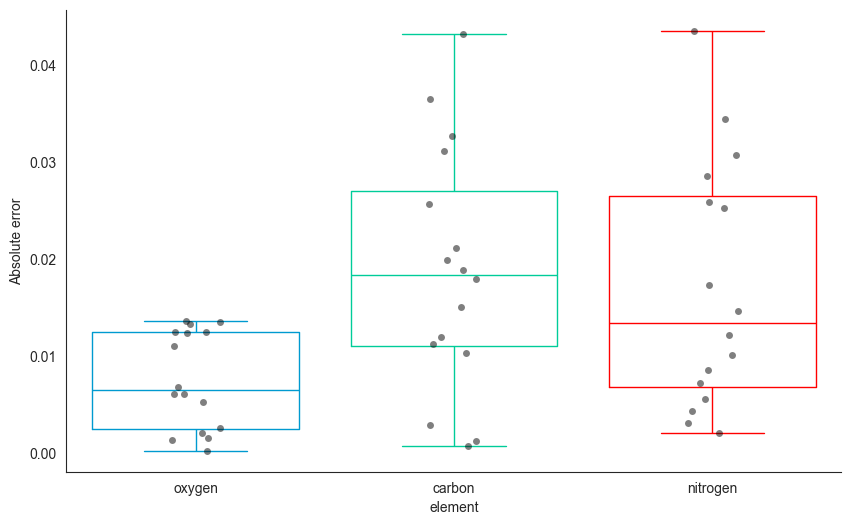

In [ ]:

df = pd.DataFrame({
    "element" : ["oxygen"] * len(Oxygen_errs) + ["carbon"] * len(Carbon_errs) + ["nitrogen"] * len(Nitrogen_errs) ,
    "value" : Oxygen_errs + Carbon_errs + Nitrogen_errs
})

palette = {"oxygen" : "#009ad0", "carbon": "#00cc99", "nitrogen": "#ff0000"}

plt.figure(figsize = (10,6))
sns.boxplot(data = df, x = "element", y = "value", palette = palette, fill = False, linewidth=1.0, fliersize=4)
sns.set_style("white")
sns.stripplot(data = df, x = "element", y = "value", color = "black", alpha = 0.5)

sns.despine()
plt.ylabel("Absolute error")
plt.xaxis
#plt.tight_layout

#for patch, element in zip(ax.artists, df["element"].unique()):
 #   print(element)
 #   patch.set_edgecolor(palette[element])
 #   patch.set_linewidth(2)
plt.show()


### Evaluate 6 element model

In [2]:
'''data_path_100mill = "/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/Data_6_element_phantom/simulations_6_element_phantom/"
X_array,X_array_nøy, y_array = load_real_data_6_element_phantom(data_path = data_path_100mill, X_length=350, include_neutron_data=True, X_length_nøy=350)#, w_gradient=True)
X_array = np.stack((X_array, X_array_nøy), axis = 2)

X_train, X_val_test, y_train, y_val_test = train_test_split(X_array, y_array, test_size = 0.20, random_state = 42)
X_val, X_test, y_val, y_test = train_test_split(X_val_test,y_val_test, test_size = 0.5, random_state = 42)
X_val = np.concatenate((X_val, X_test[:10]), axis = 0)
y_val = np.concatenate((y_val, y_test[:10]), axis = 0)
X_test = X_test[10:]
y_test = y_test[10:]
print("Dataset 1: ")
print("X_train_1 (shape): ", X_train.shape)
print("X_val (shape): ", X_val.shape)
print("X_test (shape): ", X_test.shape)
print(y_val.shape)
print(y_test.shape)'''

data_path_100mill = "/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/Data_6_element_phantom/simulations_6_element_phantom/"
data_path_100mill_ny = "/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/Data_6_element_phantom/simulations_6_element_phantom_ny/"
X_array,X_array_nøy, y_array = load_real_data_6_element_phantom(data_path = data_path_100mill, X_length=350, include_neutron_data=True, X_length_nøy=350)#, w_gradient=True)
X_array_ny,X_array_nøy_ny, y_array_ny = load_real_data_6_element_phantom(data_path = data_path_100mill_ny, X_length=350, include_neutron_data=True, X_length_nøy=350)

X_array = np.stack((X_array, X_array_nøy), axis = 2)
X_array_ny = np.stack((X_array_ny, X_array_nøy_ny), axis = 2)


X_array = np.concatenate((X_array,X_array_ny), axis = 0)
y_array = np.concatenate((y_array,y_array_ny), axis = 0)

X_train, X_val_test, y_train, y_val_test = train_test_split(X_array, y_array, test_size = 0.20, random_state = 42)
X_val, X_test, y_val, y_test = train_test_split(X_val_test,y_val_test, test_size = 0.5, random_state = 42)


print("shape of X_train", X_train.shape)
print("shape of y_train", y_train.shape)
print("shape of X_val", X_val.shape)
print("shape of y_val", y_val.shape)

shape of X_train (692, 350, 2)
shape of y_train (692, 7)
shape of X_val (86, 350, 2)
shape of y_val (86, 7)


In [4]:
pretrained_model = "/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models_6_element_phantom/wo_density/best_so_far/best_val_mae.keras"
#"/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models_6_element_phantom/wo_density/best_val_mae_N.keras"
#"/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models_6_element_phantom/wo_density/best_val_mae.keras"
#"/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models_6_element_phantom/wo_density/v02/best_val_mae.keras"
#"/scratch/Anna/Spectroscopy/simulations_prepared/composition_simulations/VSCode/spectroscopy/models_6_element_phantom/wo_density/best_val_mae.keras"
best_model = load_model(pretrained_model, compile = False, safe_mode = False)

2026-05-13 11:34:49.913958: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15050 MB memory:  -> device: 0, name: Quadro P5000, pci bus id: 0000:2d:00.0, compute capability: 6.1


In [6]:
prediction_array_X = X_test
prediction_array_y = y_test

print(prediction_array_X.shape, prediction_array_y.shape)


MAEs = []
labels = []

oksygen_true = []
carbon_true = []
nitrogen_true = []
hydrogen_true = []
ca_true = []
p_true = []
density_true = []

oksygen_pred = []
carbon_pred = []
nitrogen_pred = []
hydrogen_pred = []
ca_pred = []
p_pred = []
density_pred = []
for i in range(len(prediction_array_X)):
    y_true = prediction_array_y[i]
    #print(prediction_array_y[i])
    #print(prediction_array_X[i].shape)
    reshaped = prediction_array_X[i].reshape(1, 350, 2)
    #print(reshaped.shape)
    y_pred = best_model.predict(reshaped)#.reshape(1,350,2))
    #print(y_pred)
    #print(y_pred[1][0][0])
   
    #MAE = np.mean(np.abs(y_true - y_pred), axis = 0)
    labels.append(y_true)
    #MAEs.append(MAE)

    oksygen_true.append(y_true[0])
    carbon_true.append(y_true[1])
    nitrogen_true.append(y_true[2])
    hydrogen_true.append(y_true[3])
    ca_true.append(y_true[4])
    p_true.append(y_true[5])
    density_true.append(y_true[6])

    oksygen_pred.append(y_pred[0][0][0])
    carbon_pred.append(y_pred[0][0][1])
    nitrogen_pred.append(y_pred[0][0][2])
    hydrogen_pred.append(y_pred[0][0][3])
    ca_pred.append(y_pred[0][0][4])
    p_pred.append(y_pred[0][0][5])
    density_pred.append(y_pred[1][0][0])


print(len(labels))

(87, 350, 2) (87, 7)
1/1 [==============================] - 0s 22ms/step
87


In [101]:
Oxygen_errs = []
Carbon_errs = []
Nitrogen_errs = []
hydrogen_errs = []
ca_errs = []
P_errs = []
density_errs = []
#print(len(oksygen_pred))
for i in range(len(oksygen_pred)):
    Oxygen_errs.append(np.abs(oksygen_true[i] - oksygen_pred[i]))
    Carbon_errs.append(np.abs(carbon_true[i] - carbon_pred[i]))
    Nitrogen_errs.append(np.abs(nitrogen_true[i] - nitrogen_pred[i]))
    hydrogen_errs.append(np.abs(hydrogen_true[i] - hydrogen_pred[i]))
    ca_errs.append(np.abs(ca_true[i] - ca_pred[i]))
    P_errs.append(np.abs(p_true[i] - p_pred[i]))
    density_errs.append(np.abs(density_true[i] - density_pred[i]))

In [10]:
print("Mean oxygen absolute error:", np.round(np.mean(Oxygen_errs),4))
print("Mean carbon absolute error:", np.round(np.mean(Carbon_errs),4))
print("Mean nitrogen absolute error:", np.round(np.mean(Nitrogen_errs),4))
print("Mean hydrogen absolute error:", np.round(np.mean(hydrogen_errs),4))
print("Mean calcium absolute error:", np.round(np.mean(ca_errs),4))
print("Mean phosphorus absolute error:", np.round(np.mean(P_errs),4))
print("Mean density absolute error:", np.round(np.mean(density_errs),4))

print(np.mean(Oxygen_errs + Carbon_errs + Nitrogen_errs + hydrogen_errs + ca_errs + P_errs))

Mean oxygen absolute error: 0.0096
Mean carbon absolute error: 0.0244
Mean nitrogen absolute error: 0.0203
Mean hydrogen absolute error: 0.0105
Mean calcium absolute error: 0.0088
Mean phosphorus absolute error: 0.0124
Mean density absolute error: 0.0243
0.014356928213905556


/tmp/ipykernel_799039/2844479323.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data = df, x = "element", y = "value", palette=palette, alpha = 1)


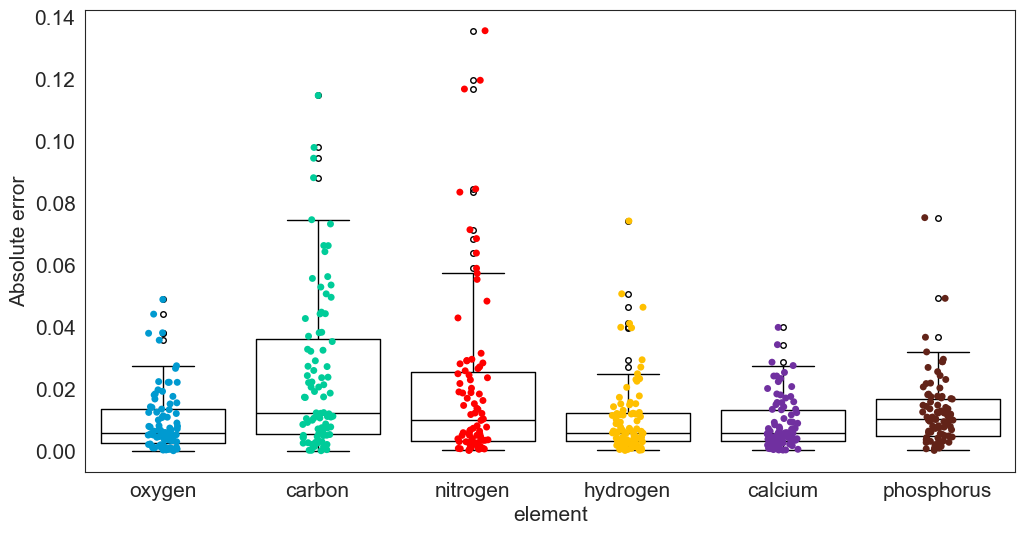

In [100]:
df = pd.DataFrame({
    "element" : ["oxygen"] * len(Oxygen_errs) + ["carbon"] * len(Carbon_errs) + ["nitrogen"] * len(Nitrogen_errs) +["hydrogen"] * len(hydrogen_errs) + ["calcium"] * len(ca_errs) + ["phosphorus"] * len(P_errs),
    "value" : Oxygen_errs + Carbon_errs + Nitrogen_errs + hydrogen_errs + ca_errs + P_errs
})

palette = {"oxygen" : "#009ad0", "carbon": "#00cc99", "nitrogen": "#ff0000", "hydrogen": "#ffc000", "calcium": "#7030a0", "phosphorus": "#622318"}

plt.figure(figsize = (12,6))
plt.rcParams['font.size'] = 15

sns.boxplot(data = df, x = "element", y = "value", color = "black", fill = False, linewidth=1.0, fliersize=4)
#sns.violinplot(data = df, x = "element", y = "value", palette = palette)
sns.set_style("white")
sns.stripplot(data = df, x = "element", y = "value", palette=palette, alpha = 1)

plt.ylabel("Absolute error")
plt.show()

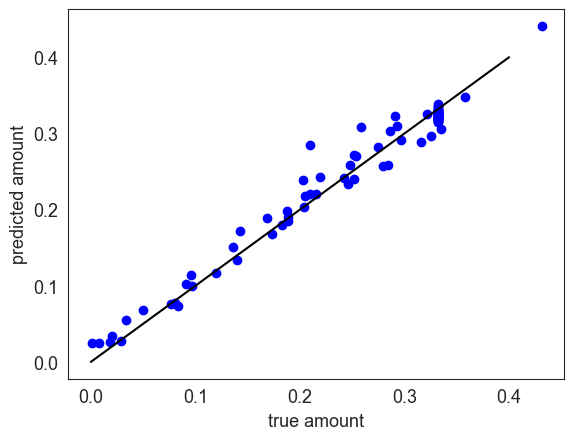

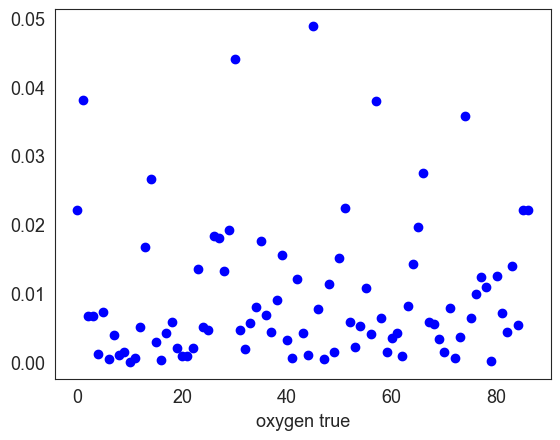

In [ ]:
A = np.linspace(0, 0.4, 100)

plt.figure()
plt.plot(p_true, p_pred, "bo")
#plt.plot(carbon_true, carbon_pred, "go")
#plt.plot(nitrogen_true, nitrogen_pred, "ro")
plt.plot(A, A, color = "black")
plt.xlabel("true amount")
plt.ylabel("predicted amount")
plt.show()

In [ ]:

for i in range(len(Oxygen_errs)):
    if Oxygen_errs[i] > 0.03:
        #print("Error in oxygen: ", np.round(Oxygen_errs[i],4), "True value: ", np.round(oksygen_true[i], 4), "Predicted value: ", np.round(oksygen_pred[i],4))
        #print("True composition:", [oksygen_true[i], carbon_true[i], nitrogen_true[i],hydrogen_true[i],ca_true[i],p_true[i]])
        #print("Predicted composition:", [oksygen_pred[i], carbon_pred[i], nitrogen_pred[i],hydrogen_pred[i],ca_pred[i],p_pred[i]])
        #print("--------------------------------------------")
        
    

Error in oxygen:  0.0381 True value:  0.3978 Predicted value:  0.3597
True composition: [0.3978, 0.195, 0.1329, 0.1738, 0.0997, 0.0008]
Predicted composition: [0.35972264, 0.2271082, 0.13785017, 0.16803813, 0.08219262, 0.025088167]
--------------------------------------------
Error in oxygen:  0.0441 True value:  0.2741 Predicted value:  0.23
True composition: [0.2741, 0.0761, 0.2684, 0.0511, 0.044, 0.2863]
Predicted composition: [0.22999856, 0.09740905, 0.26764706, 0.0517509, 0.049850587, 0.30334395]
--------------------------------------------
Error in oxygen:  0.0488 True value:  0.2939 Predicted value:  0.2451
True composition: [0.2939, 0.1791, 0.3101, 0.1488, 0.039, 0.0291]
Predicted composition: [0.24505857, 0.27700734, 0.25478473, 0.13694753, 0.059089854, 0.027111934]
--------------------------------------------
Error in oxygen:  0.0379 True value:  0.1901 Predicted value:  0.228
True composition: [0.1901, 0.057, 0.0969, 0.1507, 0.1478, 0.3575]
Predicted composition: [0.22802502

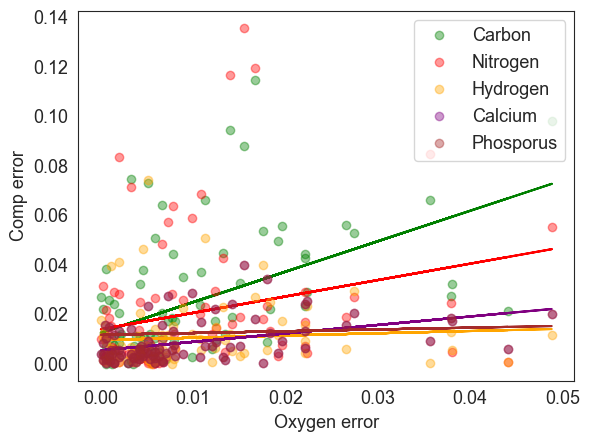

O_C_m 1.2299976417841805
O_N_m 0.6619066630466963
O_H_m 0.09059313013960352
O_Ca_m 0.3413745572575202
O_P_m 0.07237527529909067


In [63]:
O_C_m, O_C_b = np.polyfit(Oxygen_errs, Carbon_errs, 1)
O_N_m, O_N_b = np.polyfit(Oxygen_errs, Nitrogen_errs, 1)
O_H_m, O_H_b = np.polyfit(Oxygen_errs, hydrogen_errs, 1)
O_Ca_m, O_Ca_b = np.polyfit(Oxygen_errs, ca_errs, 1)
O_P_m, O_P_b = np.polyfit(Oxygen_errs, P_errs, 1)


plt.plot(Oxygen_errs,Carbon_errs, "go", label = "Carbon", alpha = 0.4)
plt.plot(Oxygen_errs, O_C_m*np.array(Oxygen_errs) + O_C_b, color = "green")

plt.plot(Oxygen_errs,Nitrogen_errs, "ro", label = "Nitrogen", alpha = 0.4)
plt.plot(Oxygen_errs, O_N_m*np.array(Oxygen_errs) + O_N_b, color = "red")

plt.plot(Oxygen_errs,hydrogen_errs, "o", color = "orange", label = "Hydrogen", alpha = 0.4)
plt.plot(Oxygen_errs, O_H_m*np.array(Oxygen_errs) + O_H_b, color = "orange")

plt.plot(Oxygen_errs,ca_errs, "o", color = "purple", label = "Calcium", alpha = 0.4)
plt.plot(Oxygen_errs, O_Ca_m*np.array(Oxygen_errs) + O_Ca_b, color = "purple")

plt.plot(Oxygen_errs,ca_errs, "o", color = "brown", label = "Phosporus", alpha = 0.4)
plt.plot(Oxygen_errs, O_P_m*np.array(Oxygen_errs) + O_P_b, color = "brown")
#plt.plot(Oxygen_errs,ca_errs, "ro", label = "hydrogen")
plt.xlabel("Oxygen error")
plt.ylabel("Comp error")
plt.legend()
plt.show()

print("O_C_m", O_C_m)
print("O_N_m", O_N_m)
print("O_H_m", O_H_m)
print("O_Ca_m", O_Ca_m)
print("O_P_m", O_P_m)


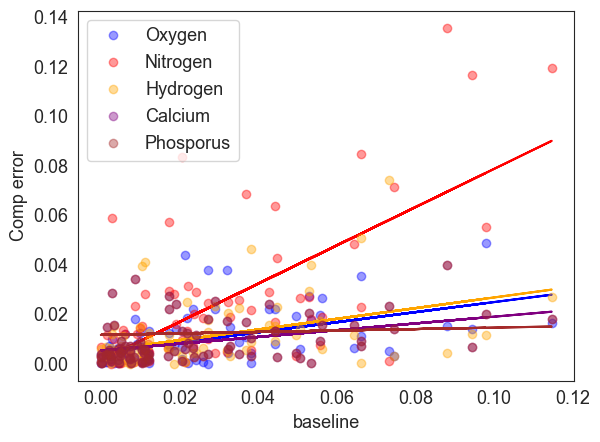

O_C_m 1.0000000000000002
O_N_m 0.7718948275940698
O_H_m 0.2155651159200329
O_Ca_m 0.1362892487805764
O_P_m 0.029275835076781054


In [64]:
baseline = Carbon_errs

O_m, O_b = np.polyfit(baseline, Oxygen_errs, 1)
O_C_m, O_C_b = np.polyfit(baseline, Carbon_errs, 1)
O_N_m, O_N_b = np.polyfit(baseline, Nitrogen_errs, 1)
O_H_m, O_H_b = np.polyfit(baseline, hydrogen_errs, 1)
O_Ca_m, O_Ca_b = np.polyfit(baseline, ca_errs, 1)
O_P_m, O_P_b = np.polyfit(baseline, P_errs, 1)


#plt.plot(baseline,Carbon_errs, "go", label = "Carbon", alpha = 0.4)
#plt.plot(baseline, O_C_m*np.array(baseline) + O_C_b, color = "green")

plt.plot(baseline,Oxygen_errs, "bo", label = "Oxygen", alpha = 0.4)
plt.plot(baseline, O_m*np.array(baseline) + O_b, color = "blue")

plt.plot(baseline,Nitrogen_errs, "ro", label = "Nitrogen", alpha = 0.4)
plt.plot(baseline, O_N_m*np.array(baseline) + O_N_b, color = "red")

plt.plot(baseline,hydrogen_errs, "o", color = "orange", label = "Hydrogen", alpha = 0.4)
plt.plot(baseline, O_H_m*np.array(baseline) + O_H_b, color = "orange")

plt.plot(baseline,ca_errs, "o", color = "purple", label = "Calcium", alpha = 0.4)
plt.plot(baseline, O_Ca_m*np.array(baseline) + O_Ca_b, color = "purple")

plt.plot(baseline,ca_errs, "o", color = "brown", label = "Phosporus", alpha = 0.4)
plt.plot(baseline, O_P_m*np.array(baseline) + O_P_b, color = "brown")
#plt.plot(Oxygen_errs,ca_errs, "ro", label = "hydrogen")
plt.xlabel("baseline")
plt.ylabel("Comp error")
plt.legend()
plt.show()

print("O_C_m", O_C_m)
print("O_N_m", O_N_m)
print("O_H_m", O_H_m)
print("O_Ca_m", O_Ca_m)
print("O_P_m", O_P_m)

In [91]:
Oxygen_errs = []
Carbon_errs = []
Nitrogen_errs = []
hydrogen_errs = []
ca_errs = []
P_errs = []
density_errs = []
#print(len(oksygen_pred))
for i in range(len(oksygen_pred)):
    Oxygen_errs.append(oksygen_true[i] - oksygen_pred[i])
    Carbon_errs.append(carbon_true[i] - carbon_pred[i])
    Nitrogen_errs.append(nitrogen_true[i] - nitrogen_pred[i])
    hydrogen_errs.append(hydrogen_true[i] - hydrogen_pred[i])
    ca_errs.append(ca_true[i] - ca_pred[i])
    P_errs.append(p_true[i] - p_pred[i])
    density_errs.append(density_true[i] - density_pred[i])

In [105]:
import scipy
E = np.vstack([Oxygen_errs, Carbon_errs, Nitrogen_errs, hydrogen_errs, ca_errs, P_errs]).T
corr,_ = scipy.stats.spearmanr(E)
#np.corrcoef(E, rowvar=False)

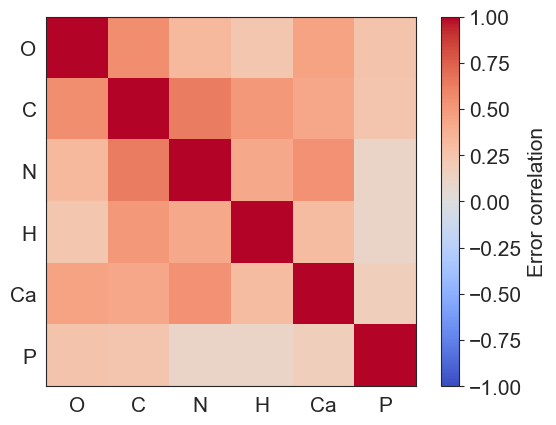

Oxygen
0.9999999999999999
0.548079026026099
0.32106145658671714
0.23365167310636434
0.44847634322373686
0.25253335277393013
Carbon
0.548079026026099
0.9999999999999999
0.6259568418750454
0.5046110665597434
0.4274987242108332
0.2398665889042793
Nitrogen
0.32106145658671714
0.6259568418750454
0.9999999999999999
0.4202996281985857
0.5338084129182765
0.10949916162426185
hydrogen
0.23365167310636434
0.5046110665597434
0.4202996281985857
0.9999999999999999
0.303838302835897
0.11044689071954507
Ca
0.44847634322373686
0.4274987242108332
0.5338084129182765
0.303838302835897
0.9999999999999999
0.17104687613909747


In [106]:
labels = ["O", "C", "N", "H", "Ca", "P"]
plt.imshow(corr, vmin = -1, vmax = 1,cmap = "coolwarm")
plt.colorbar(label = "Error correlation")
plt.xticks(range(6),labels)
plt.yticks(range(6),labels)
plt.show()

print("Oxygen")
for i in range(6):
    print(corr[0, i])

print("Carbon")
for i in range(6):
    print(corr[1, i])

print("Nitrogen")
for i in range(6):
    print(corr[2, i])

print("hydrogen")
for i in range(6):
    print(corr[3, i])


print("Ca")
for i in range(6):
    print(corr[4, i])